### 1. Imports

In [5]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

### 2. Load data set

In [12]:
df = pd.read_csv('data/bioactivity_data_3class_pIC50_pubchem_fp.csv')
df = df.drop('Unnamed: 0', axis=1)
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.301030
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.568636
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.744727
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.958607
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.399027
1620,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.275724
1621,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.962574
1622,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.389340


### 3 Input features

#### 3.1 Input features

In [13]:
X = df.drop('pIC50', axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1620,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1621,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1622,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


#### 3.2 Output features

In [14]:
y = df.pIC50
y

0       5.301030
1       5.568636
2       5.744727
3       4.958607
4       5.000000
          ...   
1619    6.399027
1620    7.275724
1621    6.962574
1622    6.389340
1623    7.050610
Name: pIC50, Length: 1624, dtype: float64

#### 3.3 Data dimension

In [15]:
X.shape

(1624, 881)

In [16]:
y.shape

(1624,)

#### 3.4 Remove low variance features

In [17]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(0.8 * (1 - 0.8)))
X = selection.fit_transform(X)

In [18]:
X.shape

(1624, 169)

### 4. Data split (80/20)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
X_test.shape, y_test.shape

((325, 169), (325,))

### 5. Build regression model using Random Forest

In [24]:
import numpy as np
np.random.seed(714)
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)
r2 = model.score(X_test, y_test)
r2

0.7916128530773988

In [25]:
y_pred = model.predict(X_test)

### 6. Scatter plot of Experimental vs. Predicted pIC50 Values

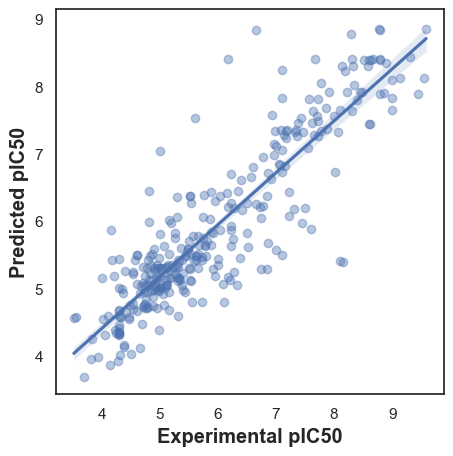

In [29]:
import matplotlib.pyplot as plt

sns.set_theme(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.4})
ax.set_xlabel("Experimental pIC50", fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.figure.set_size_inches(5, 5)
plt.show()